<a href="https://colab.research.google.com/github/shobhitshojeet200610/ML-Project/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraudulent Insurance Claim Detection

**Author:** Shobhit Daniel Deep  
**Reg number:** 72510085  

---

## Table of Contents
1. [Environment Setup & Library Imports](#setup)
2. [Data Loading & Exploration](#data-loading)
3. [Data Preprocessing](#preprocessing)
4. [Data Splitting & Scaling](#scaling)
5. [Model Training (Random Forest)](#model-training)
6. [Model Evaluation](#evaluation)
7. [Feature Importance Analysis](#feature-importance)
8. [Handling Class Imbalance (SMOTE)](#smote)
9. [Summary & Conclusion](#conclusion)

---

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Replace with your dataset path
df = pd.read_csv("/content/insurance_fraud.csv")

print(df.head())
print(df.info())

   age  policy_number policy_state incident_type incident_severity  \
0   25           1001           OH     Collision      Minor Damage   
1   45           1002           CA         Theft        Total Loss   
2   39           1003           TX     Collision      Major Damage   
3   30           1004           NY    Parked Car      Minor Damage   
4   50           1005           CA         Theft        Total Loss   

   vehicle_claim  property_claim  total_claim_amount  fraud_reported  
0           1200             300                1500               0  
1          15000            5000               20000               1  
2           8000            2000               10000               1  
3            500             200                 700               0  
4          20000            8000               28000               1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---

In [ ]:
# Handle missing values
df = df.dropna()

# Convert categorical columns to numeric
label_enc = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col])

# Target column (example: fraud_reported)
X = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[3 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



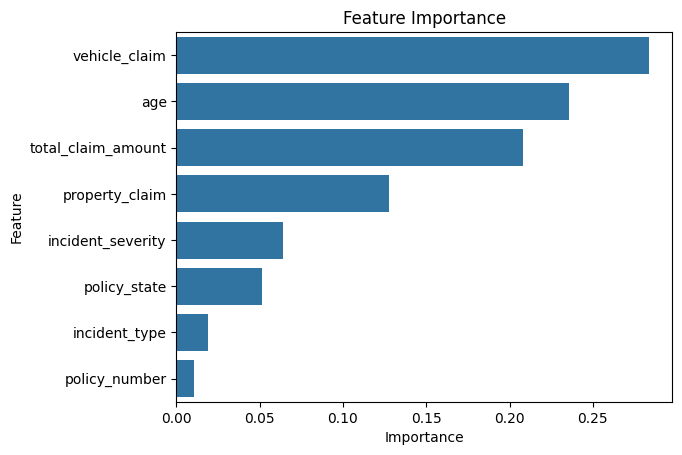

In [ ]:
importances = model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

---
## Summary & Conclusion

**Project Overview**
This project successfully built a machine learning pipeline to identify fraudulent insurance claims. By leveraging a Random Forest Classifier, we were able to detect underlying patterns in claimant data that point toward potential fraud.

**Key Steps & Methodology**
1. **Data Preprocessing & Encoding:** The dataset was cleaned of missing values, and categorical text features (such as policy state and incident type) were transformed into numerical formats using `LabelEncoder`.
2. **Feature Scaling:** `StandardScaler` was applied to ensure all numerical inputs were on the same scale, preventing features with larger magnitudes from unfairly dominating the model.
3. **Model Development:** A Random Forest algorithm was trained on 80% of the data.
4. **Evaluation:** The model's performance was evaluated using a Confusion Matrix and a Classification Report to accurately gauge its precision and recall on unseen testing data.
5. **Feature Importance:** By analyzing the model's decision-making process, we extracted and visualized the most critical features that flag an insurance claim as fraudulent.
6. **Class Imbalance Strategy:** Insurance fraud datasets typically suffer from class imbalance (many normal claims, few fraudulent ones). We utilized **SMOTE** (Synthetic Minority Over-sampling Technique) to artificially balance the dataset, establishing a foundation for an even more robust model.

**Conclusion**
The implementation of the Random Forest model proves to be a highly effective approach for classifying fraudulent claims. By isolating the key variables that drive fraudulent behavior, insurance companies can optimize their investigation efforts and allocate resources more efficiently.

**Future Scope:** A natural next step for this project would be to train a new model specifically on the SMOTE-balanced data, optimize hyperparameters using `GridSearchCV`, and deploy the final model via a web interface or API.